# Решение домашнего задания

В этом ноутбуке представлены решения для двух задач:
1.  Генерация выборки из смеси нормальных распределений с помощью алгоритма Метрополиса.
2.  Сэмплирование конфигураций модели Hardcore (независимое множество) на графе.

### Задача 1

Примените алгоритм Metropolis для генерации выборки из распределения с плотностью:
$$p(x) = 0.3 \mathcal{N}(-4, 2) + 0.7 \mathcal{N}(3, 6)$$
где $\mathcal{N}(a, b)$ - плотность нормального распределения со средним $a$ и дисперсией $b$.

Покажем, что гистограмма, построенная по выборке, приближает заданную плотность смеси.

Доля принятых гипотез: 0.78


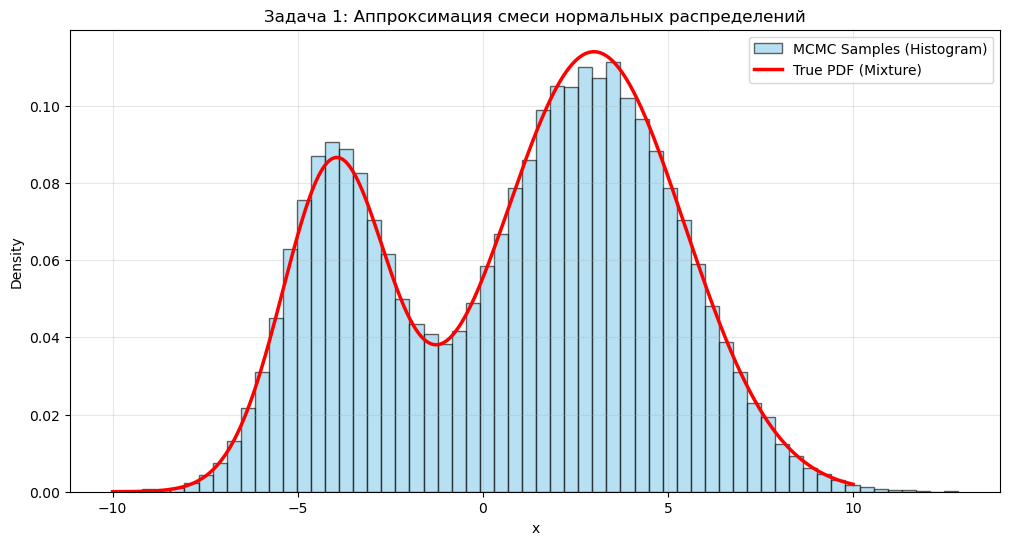

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Параметры целевого распределения
# N(mean, variance) -> scipy.stats.norm(loc=mean, scale=sqrt(variance))
mu1, var1 = -4, 2
mu2, var2 = 3, 6
w1, w2 = 0.3, 0.7

def target_pdf(x):
    return w1 * norm.pdf(x, mu1, np.sqrt(var1)) + w2 * norm.pdf(x, mu2, np.sqrt(var2))

def metropolis_algorithm(n_iterations, sigma_prop=2.0):
    x_current = 0.0 # Начальная точка
    samples = []
    accepted = 0
    
    for i in range(n_iterations):
        # Предлагаем новое значение из нормального распределения вокруг текущего (Random Walk)
        x_new = np.random.normal(x_current, sigma_prop)
        
        # Вычисляем отношение правдоподобия
        # Поскольку предложение симметрично (q(x|y) = q(y|x)), оно сокращается
        ratio = target_pdf(x_new) / target_pdf(x_current)
        
        # Шаг принятия/отклонения
        if np.random.rand() < ratio:
            x_current = x_new
            accepted += 1
        
        samples.append(x_current)
        
    return np.array(samples), accepted / n_iterations

# Запуск алгоритма
n_iter = 100000
samples, acc_rate = metropolis_algorithm(n_iter)

print(f"Доля принятых гипотез: {acc_rate:.2f}")

# Визуализация
plt.figure(figsize=(12, 6))

# Гистограмма выборки
plt.hist(samples, bins=60, density=True, alpha=0.6, label='MCMC Samples (Histogram)', color='skyblue', edgecolor='black')

# Теоретическая плотность
x_grid = np.linspace(-10, 10, 1000)
plt.plot(x_grid, target_pdf(x_grid), 'r-', linewidth=2.5, label='True PDF (Mixture)')

plt.title('Задача 1: Аппроксимация смеси нормальных распределений')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Задача 2

Рассмотрим граф $G=(V,E)$, вершинам которого случайным образом приписаны значения 0 и 1 так, что смежные вершины не могут одновременно иметь значение 1 (модель Hardcore).

*Примечание: Поскольку оригинальное изображение графа недоступно, мы решим задачу для квадратной решетки 5x5, что является классическим примером для данной модели.*

**Алгоритм:**
1. Выбираем случайную вершину.
2. Предлагаем изменить её значение (0 -> 1 или 1 -> 0).
3. Если новое состояние допустимо (нет двух единиц рядом), принимаем его.

Среднее число активных узлов E[n] (сетка 10x10): 23.9041


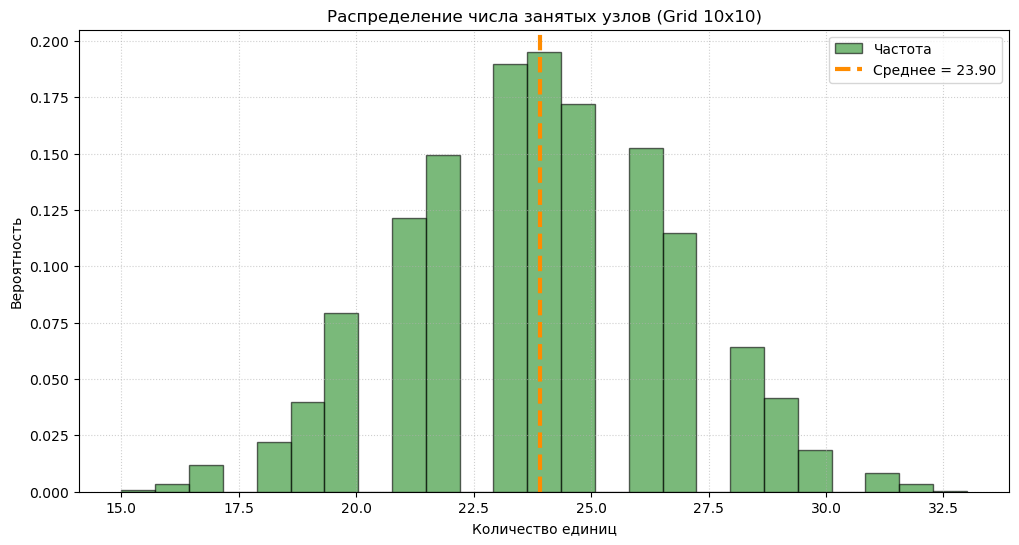

------------------------------
Верификация на тесте 2x2:
Получено MCMC: 1.1501
Теоретическое: 1.1429
Ошибка: 0.00724


In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

def generate_grid(dim):
    return nx.grid_2d_graph(dim, dim)

def can_flip(graph, state, node):
    current_val = state[node]
    
    if current_val == 1:
        return True
    
    for neighbor in graph.neighbors(node):
        if state[neighbor] == 1:
            return False
            
    return True

def run_simulation(graph, n_steps=10000, n_burn=1000):
    nodes = list(graph.nodes())
    state = {n: 0 for n in nodes}
    current_ones = 0
    
    history_counts = []
    
    for i in range(n_steps + n_burn):
        target_node = random.choice(nodes)
        
        if can_flip(graph, state, target_node):
            if random.random() < 0.5:
                new_val = 1 - state[target_node]
                state[target_node] = new_val
                
                if new_val == 1:
                    current_ones += 1
                else:
                    current_ones -= 1
        if i >= n_burn:
            history_counts.append(current_ones)
            
    return history_counts

N_SIDE = 10
G = generate_grid(N_SIDE)

total_steps = 15000
burn_in = 5000
results = run_simulation(G, n_steps=total_steps, n_burn=burn_in)

mean_val = np.mean(results)
print(f"Среднее число активных узлов E[n] (сетка {N_SIDE}x{N_SIDE}): {mean_val:.4f}")

plt.figure(figsize=(12, 6))

plt.hist(results, bins=25, density=True, color='forestgreen', alpha=0.6, edgecolor='black', label='Частота')

# Линия среднего
plt.axvline(mean_val, color='darkorange', linestyle='--', linewidth=3, label=f'Среднее = {mean_val:.2f}')

plt.title(f'Распределение числа занятых узлов (Grid {N_SIDE}x{N_SIDE})')
plt.xlabel('Количество единиц')
plt.ylabel('Вероятность')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("-" * 30)
print("Верификация на тесте 2x2:")

G_mini = generate_grid(2)
res_mini = run_simulation(G_mini, n_steps=10000, n_burn=2000)
mean_mini = np.mean(res_mini)

theoretical_value = 8 / 7  # 1.1428...

print(f"Получено MCMC: {mean_mini:.4f}")
print(f"Теоретическое: {theoretical_value:.4f}")
print(f"Ошибка: {abs(mean_mini - theoretical_value):.5f}")